<a href="https://colab.research.google.com/github/gyeongee/TIL/blob/main/%EB%9E%9C%EB%8D%A4%ED%8F%AC%EB%A0%88%EC%8A%A4%ED%8A%B8_%EC%82%AC%EC%9A%A9%EC%9E%90%ED%96%89%EB%8F%99%EC%9D%B8%EC%8B%9D%EC%98%88%EC%B8%A1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score


In [ ]:
import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/ML_26/human+activity+recognition+using+smartphones')
print(os.getcwd())

/content/drive/MyDrive/Colab Notebooks/ML_26/human+activity+recognition+using+smartphones


In [ ]:
df=pd.read_csv('./UCI HAR Dataset/features.txt',sep=r'\s+',
               header=None,names=['column_index','column_name'])
feature_names=df.iloc[:,1].values.tolist()
print(f'전체 피처명에서 10개만 추출:{feature_names[:10]}')

전체 피처명에서 10개만 추출:['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X']


In [ ]:
def get_new_feature_name_df(old_df):
    # 중복 순번 생성= cumcount()
    feature_dup_df=pd.DataFrame(data=old_df.groupby('column_name').cumcount(),
                               columns=['dup_cnt'])

    # 인덱스 맞추기
    feature_dup_df = feature_dup_df.reset_index()
    new_df= pd.merge(old_df.reset_index(),feature_dup_df,how='outer')

    # 중복이면 suffix 붙이기
    new_df['column_name'] = new_df['column_name'] + '_' + new_df['dup_cnt'].astype(str)
    new_df.loc[new_df['dup_cnt'] == 0, 'column_name'] = new_df['column_name'].str.replace('_0','')
    new_df=new_df.drop(['index'],axis=1)
    return new_df

In [ ]:
import pandas as pd

def get_human_dataset():

    # 각 데이터 파일은 공백으로 분리되어 있으므로 read_csv에서 공백문자를 sep로 할당
    new_df = get_new_feature_name_df(df)

    # DataFrame에 피처명을 칼럼으로 부여하기 위해 리스트 객체로 다시 변환
    feature_name = new_df.iloc[:,1].values.tolist()

    # 학습 피처 데이터세트와 테스트 피처 데이터를 DataFrame으로 로딩,칼럼명은 feature_name 적용
    X_train = pd.read_csv('./UCI HAR Dataset/train/X_train.txt',sep=r'\s+',names=feature_name)
    X_test = pd.read_csv('./UCI HAR Dataset/test/X_test.txt',sep=r'\s+',names=feature_name)

    # 학습 레이블과 테스트 레이블 데이터를 DataFrame으로 로딩하고 칼럼명은 action으로 부여
    y_train=pd.read_csv('./UCI HAR Dataset/train/y_train.txt',sep=r'\s+',header=None,names=['action'])
    y_test = pd.read_csv('./UCI HAR Dataset/test/y_test.txt',sep=r'\s+',header=None,names=['action'])

    # 로드된 학습/테스트용 DataFrame을 모두 반환
    return X_train,X_test,y_train,y_test

X_train,X_test, y_train,y_test = get_human_dataset()

In [ ]:
# 랜덤포레스트 학습 및 별도의 테스트 세트로 예측 성능 평가
rf = RandomForestClassifier(random_state=0,max_depth=8)
rf.fit(X_train,y_train)
pred = rf.predict(X_test)
print(f'랜덤포레스트의 정확도:{accuracy_score(y_test,pred):.4f}')

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


랜덤포레스트의 정확도:0.9220


In [ ]:
from sklearn.model_selection import GridSearchCV

params={
    'max_depth':[8,12,16,20,24],
    'min_samples_leaf':[2,4,6,8,10],
    'min_samples_split':[2,4,6,8,10,12,14]
}

# RandomForestClassifier 객체 생성 후 GridSearchCV 수행
rf = RandomForestClassifier(n_estimators=100,random_state=0,n_jobs=-1)
grid_cv = GridSearchCV(rf,params,cv=2,n_jobs=-1)
grid_cv.fit(X_train,y_train)

print(f'최적 하이퍼 파라미터:\n{grid_cv.best_params_}')
print(f'최고 예측 정확도:{grid_cv.best_score_}')

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


최적 하이퍼 파라미터:
{'max_depth': 16, 'min_samples_leaf': 10, 'min_samples_split': 2}
최고 예측 정확도:0.9182535364526659


In [ ]:
rf1=RandomForestClassifier(n_estimators=100,max_depth=16,min_samples_leaf=10,min_samples_split=2,random_state=0)
rf1.fit(X_train,y_train)
pred=rf1.predict(X_test)
print(f'예측 정확도:{accuracy_score(y_test,pred):.4f}')

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


예측 정확도:0.9250


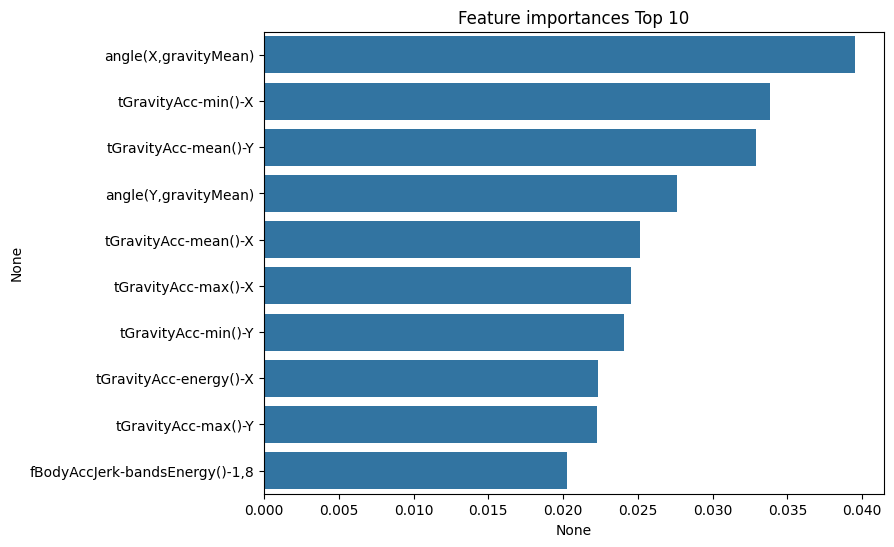

In [ ]:
f_importance_values=rf1.feature_importances_
f_importance=pd.Series(f_importance_values,index=X_train.columns)
importance_top_10=f_importance.sort_values(ascending=False)[:10]

plt.figure(figsize=(8,6))
plt.title('Feature importances Top 10')
sns.barplot(x=importance_top_10,y=importance_top_10.index)
plt.show()